### optimized Decision Tree

In [ ]:
import numpy as np
import pandas as pd

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, class_label=None, proba=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.class_label = class_label
        self.proba = proba

class DecisionTreeFromScratch_Opt_Time:
    def __init__(self, max_depth=10, min_samples_leaf=10, min_samples_split=20, 
                 max_features=None, pos_weight=5.0, max_leaf_nodes=None, 
                 min_impurity_decrease=0.0, min_cost_complexity=1e-6, random_state=42):
        # Pre-Pruning
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split  = min_samples_split
        self.max_leaf_nodes = max_leaf_nodes   # Global leaf counter and stops splitting when limit reached
        self.min_impurity_decrease = min_impurity_decrease
        self.max_features = max_features  # Can be None, int, float, 'sqrt', 'log2'
        # Post-Pruning
        self.ccp_alpha = min_cost_complexity # ccp_alpha Simple postpruning stub that removes subtrees 
                                    # whose impurity improvement is less than alpha

        # Extra Pruning for this Dataset
        self.pos_weight = pos_weight # Imbalance Handling
        
        self.random_state = random_state
        np.random.seed(random_state)

        self.root = None
        self.leaf_count = 0
        self.n_features_ = None
    
    def _best_split(self, X, y, indices):
        """Highly vectorized best split using cumulative sums."""
        m = len(indices)

        if m < self.min_samples_split:
            return None, None

        best_gini = float('inf')
        best_feature, best_threshold = None, None

        parent_gini = 0.0  # Will compute later

        n_features = X.shape[1]
        k = 1
        # max_features regularization 
        if self.max_features is None:
            # features = np.arange(n_features)
            k = n_features
        else: 
            if isinstance(self.max_features, str):
                if self.max_features == 'sqrt':
                    k = max(1, int(np.sqrt(n_features)))
                elif self.max_features == 'log2':
                    k = max(1, int(np.log2(n_features)))
                else:
                    k = n_features
            elif isinstance(self.max_features, float) and 0 < self.max_features < 1:
                k = max(1, int(self.max_features * n_features))
            else:
                k = max(1, int(self.max_features))  
        
        k = min(k, n_features)
        feature_list = np.random.choice(n_features, k, replace=False)

        # Parent gini ( for min_impurity_decrease)
        y_subset = y[indices]
        pos = np.sum(y_subset == 1)
        p = pos / m
        parent_gini = 1 - (p**2 + (1-p)**2)


        for feat_idx in feature_list:
            # Sort indices by current features
            sorted_idx = indices[np.argsort(X[indices, feat_idx])]
            X_sorted = X[sorted_idx, feat_idx]
            y_sorted = y[sorted_idx]

            # Convert labels to 0/1 (important for speed)
            y_bin = (y_sorted == 1).astype(np.int32)

            # Total counts
            total_pos = y_bin.sum()
            total_neg = m - total_pos

            # Cumulative sums → vectorized left counts
            left_pos = np.cumsum(y_bin)[:-1]
            left_neg = np.cumsum(1 - y_bin)[:-1]

            # Right counts
            right_pos = total_pos - left_pos
            right_neg = total_neg - left_neg

            # Valid splits mask
            split_points = np.arange(1, m)
            valid = (
                (split_points >= self.min_samples_leaf) &
                ((m - split_points) >= self.min_samples_leaf) &
                (X_sorted[1:] != X_sorted[:-1])
            )

            if not np.any(valid):
                continue

            # Gini computation (vectorized)
            left_total = left_pos + left_neg
            right_total = right_pos + right_neg

            # Avoid division by zero
            left_total = np.maximum(left_total, 1)
            right_total = np.maximum(right_total, 1)

            p_left_pos = left_pos / left_total
            p_left_neg = left_neg / left_total

            p_right_pos = right_pos / right_total
            p_right_neg = right_neg / right_total

            gini_left = 1 - (p_left_pos**2 + p_left_neg**2)
            gini_right = 1 - (p_right_pos**2 + p_right_neg**2)

            # Weighted gini
            weights_left = left_total / m
            weights_right = right_total / m

            weighted_gini = weights_left * gini_left + weights_right * gini_right

            # Apply valid mask
            weighted_gini[~valid] = np.inf

            # min_impurity_decrease regularization
            impurity_decrease = parent_gini - weighted_gini

            weighted_gini[impurity_decrease < self.min_impurity_decrease] = np.inf

            # Find best split for this feature
            idx = np.argmin(weighted_gini)
            gini = weighted_gini[idx]

            if gini < best_gini:
                best_gini = gini
                best_feature = feat_idx
                best_threshold = (X_sorted[idx] + X_sorted[idx + 1]) / 2

            # Early stopping for already optimized gain
            if best_gini < 1e-6:
                break

        return best_feature, best_threshold

    
    # Recursive tree building (No Array Copying)
    def _build_tree(self, X, y, indices, depth=0):
        """Recursive tree building."""
        m = len(indices)
        if m==0:
            return Node(class_label=0, proba=0.5)
        
        y_subset = y[indices]

        pos = np.sum(y_subset == 1)
        proba = pos / m if m > 0 else 0.5

        # max_leaf_nodes regularization
        if self.max_leaf_nodes is not None:
            self.leaf_count += 1
            if self.leaf_count > self.max_leaf_nodes:
                # Force leaf even if we could split
                label=1 if proba >= (1.0 / self.pos_weight) else 0
                return Node(class_label=label, proba = proba)

        # stopping condition.
        if (depth >= self.max_depth or 
            m < self.min_samples_split or 
            len(np.unique(y_subset)) == 1):
            label = 1 if proba >= (1.0 / self.pos_weight) else 0
            return Node(class_label=label, proba=proba)
        
        feature, threshold = self._best_split(X, y, indices)

        if feature is None: 
            label = 1 if proba >= (1.0 / self.pos_weight) else 0
            return Node(class_label=label, proba=proba)
        
        mask = X[indices, feature] <= threshold
        left_indices = indices[mask]
        right_indices = indices[~mask]

        left = self._build_tree(X, y, left_indices, depth + 1)
        right = self._build_tree(X, y, right_indices, depth + 1)
        return Node(feature=feature, threshold=threshold, left=left, right=right)
    

    def _calculate_gini(self, proba):
        p = np.clip(proba, 1e-15, 1 - 1e-15)
        return 1 - (p**2 + (1-p)**2)

    def _prune(self, node):
        """Simple post-pruning using min_cost_complexity."""
        if node is None:
            return None
        
        if node.left is not None:
            node.left = self._prune(node.left)
        if node.right is not None:
            node.right = self._prune(node.right)

        if node.left is None or node.right is None:
            return node

        if self.ccp_alpha > 0:
            if (node.left and node.left.class_label is not None and 
                node.right and node.right.class_label is not None):
                left_w = node.left.proba if node.left.proba is not None else 0.5
                right_w = node.right.proba if node.right.proba is not None else 0.5
                
                total_w = left_w + right_w
                if total_w > 0:
                    left_w /= total_w
                    right_w /= total_w
                
                gini_left = self._calculate_gini(node.left.proba)
                gini_right = self._calculate_gini(node.right.proba)

                weighted_gini = left_w * gini_left + right_w * gini_right
                parent_gini = self._calculate_gini(node.proba) if node.proba is not None else 0.5

                if (parent_gini - weighted_gini) < self.ccp_alpha:
                    return Node(class_label=node.class_label, 
                                proba=node.proba
                    )
        return node

    # Fit
    def fit(self, X, y):
        """Fit the model."""
        X = np.array(X, dtype=np.float32)
        y = (np.array(y).ravel() == 1).astype(np.int32)

        self.n_features_ = X.shape[1]
        indices = np.arange(len(y))
        self.leaf_count = 0
        self.root = self._build_tree(X, y, indices)

        # Post-Pruning
        if self.ccp_alpha > 0:
            self.root = self._prune(self.root)
        
        return self

    def _predict_one(self, x, node):
        """Traverse tree for one sample."""
        if node is None:
            return 0
        
        if node.class_label is not None:
            return node.class_label
        
        if node.feature is None or node.threshold is None:
            # Fallback to majority (rare edge case after aggressive pruning)
            return 1 if (node.proba or 0.5) >= (1.0 / self.pos_weight) else 0
        
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
        
    def predict(self, X):
        """Predict the model for a test case."""
        X = np.array(X, dtype=np.float32)
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_proba_one(self, x, node):
        """Traverse tree for one sample to get target probability."""
        if node is None:
            return 0.5

        if node.proba is not None:
            return node.proba
        
        if node.feature is None or node.threshold is None:
            # Fallback to majority (rare edge case after aggressive pruning)
            return float(node.proba) if node.proba is not None else 0.5

        if x[node.feature] <= node.threshold:
            return self._predict_proba_one(x, node.left)
        else:
            return self._predict_proba_one(x, node.right)
        
    def predict_proba(self, X):
        """Predict the probability of target with model for a test case."""
        X = np.array(X, dtype=np.float32)
        proba = np.array([self._predict_proba_one(x, self.root) for x in X])
        proba = np.nan_to_num(proba, nan=0.5)
        return proba

- Time Complexity: **O(n_features * n_samples)**

## Dataset - Porto Seguro Safe Driver Prediction

In [64]:
df_train = pd.read_csv('../Cleaned-Dataset/train.csv')
df_test = pd.read_csv('../Cleaned-Dataset/test.csv')


In [65]:

def dataset_split(df_train, df_test):
    train_samples = int(df_train.shape[0] * 0.8)

    X_train, y_train = df_train[:train_samples].drop(columns=['target']), df_train[:train_samples]['target']
    X_valid, y_valid = df_train[train_samples:].drop(columns=['target']), df_train[train_samples:]['target']

    test = df_test
    return X_train, y_train, X_valid, y_valid, test


In [66]:
# Encoding 
# Target encode only high-cardinality column

def encode_cat_cols(X_train, y_train, X_valid, y_valid, test):
    cat_cols_target = ["ps_car_11_cat"]

    cat_cols_final = [col for col in X_train.columns if col.endswith("_cat")]
    cat_cols_onehot = [col for col in cat_cols_final if col not in cat_cols_target]

    from category_encoders import TargetEncoder, OneHotEncoder
    # --- Target Encoding ---
    target_encoder = TargetEncoder(cols=cat_cols_target, smoothing=0.3)

    X_train = target_encoder.fit_transform(X_train, y_train)
    X_valid = target_encoder.transform(X_valid)
    test = target_encoder.transform(test)

    # --- One Hot Encoding ---
    onehot_encoder = OneHotEncoder(cols=cat_cols_onehot, use_cat_names=True)

    X_train = onehot_encoder.fit_transform(X_train)
    X_valid = onehot_encoder.transform(X_valid)
    test = onehot_encoder.transform(test)
    return X_train, y_train, X_valid, y_valid, test

In [67]:
X_train, y_train, X_valid, y_valid, test =  dataset_split(df_train, df_test)
# Encoding 
X_train, y_train, X_valid, y_valid, test = encode_cat_cols(X_train, y_train, X_valid, y_valid, test)

#### Hyper parameter tuning 

In [68]:
sample_size = 100000
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sub, y_train_sub = X_train.iloc[idx], y_train.iloc[idx]
# X_valid_sub, y_valid_sub = X_valid.iloc[idx], y_valid.iloc[idx]

# Default Parameters (remaining fixed while tuning one)
default_params = {
    'max_depth': 8,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_cost_complexity': 1e-6,
    'pos_weight': 5,
    'random_state': 42
}


In [80]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def tune_and_plot(param_name, param_values, xlabel):
    """Tune one parameter while others default."""
    auc_scores = []
    for val in param_values:
        params = default_params.copy()
        params[param_name] = val
        try:
            model_DT = DecisionTreeFromScratch_Opt_Time(**params)
            model_DT.fit(X_train_sub, y_train_sub)
            proba_val = model_DT.predict_proba(X_valid)
            auc = roc_auc_score(y_valid, proba_val)
            # Safe printing: handle None specially
            val_str = "None" if val is None else str(val)

            print(f" {param_name}={val_str:10} -> AUC = {auc:.5f}")
            auc_scores.append(auc)
        
        except Exception as e:
            print(f" {param_name}={val} → ERROR: {type(e).__name__} - {e}")
            auc_scores.append(np.nan)

    # Prepare x-axis for plotting (convert None to string)
    x_ticks = ["None" if v is None else str(v) for v in param_values]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(param_values)), auc_scores, marker='o', linewidth=2, markersize=8)
    plt.xticks(range(len(param_values)), x_ticks, rotation=45)
    plt.title(f'AUC Score vs {param_name}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Validation AUC Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return auc_scores



=== TUNING max_depth (pre-pruning depth control) ===
 max_depth=3          -> AUC = 0.55778
 max_depth=4          -> AUC = 0.56928
 max_depth=5          -> AUC = 0.57715
 max_depth=6          -> AUC = 0.58140
 max_depth=7          -> AUC = 0.57009
 max_depth=8          -> AUC = 0.57272
 max_depth=9          -> AUC = 0.55095
 max_depth=10         -> AUC = 0.54781
 max_depth=12         -> AUC = 0.55107
 max_depth=15         -> AUC = 0.51577


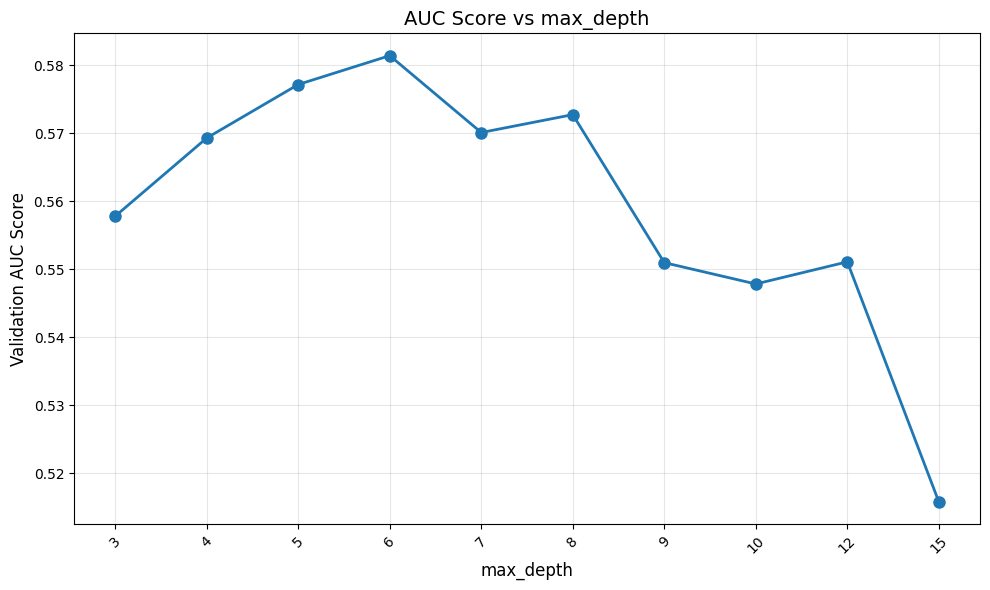

[0.5577829613991367,
 0.5692826628386507,
 0.5771519615086419,
 0.5813970527570228,
 0.5700884526626846,
 0.572718613206723,
 0.5509495627572619,
 0.5478108248411698,
 0.551068665466576,
 0.5157735020062372]

In [81]:
print("\n=== TUNING max_depth (pre-pruning depth control) ===")
max_depth_vals = [3, 4, 5, 6, 7, 8, 9, 10, 12, 15]
tune_and_plot('max_depth', max_depth_vals, 'max_depth')


=== TUNING min_samples_split (pre-pruning minimum split size) ===
 min_samples_split=2          -> AUC = 0.57830
 min_samples_split=3          -> AUC = 0.57830
 min_samples_split=4          -> AUC = 0.57830
 min_samples_split=5          -> AUC = 0.57830
 min_samples_split=6          -> AUC = 0.57830
 min_samples_split=7          -> AUC = 0.57830
 min_samples_split=8          -> AUC = 0.57830
 min_samples_split=9          -> AUC = 0.57830
 min_samples_split=10         -> AUC = 0.57830
 min_samples_split=20         -> AUC = 0.57272
 min_samples_split=50         -> AUC = 0.57602
 min_samples_split=100        -> AUC = 0.57725
 min_samples_split=200        -> AUC = 0.57743
 min_samples_split=500        -> AUC = 0.58058
 min_samples_split=600        -> AUC = 0.58058
 min_samples_split=700        -> AUC = 0.58058
 min_samples_split=800        -> AUC = 0.58622
 min_samples_split=900        -> AUC = 0.58867
 min_samples_split=1000       -> AUC = 0.58759


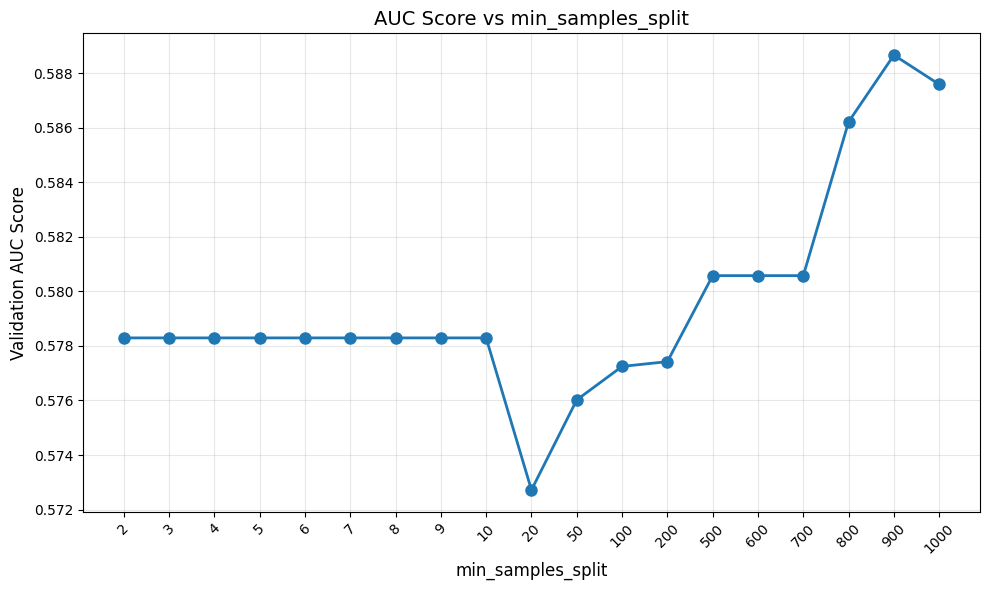

[0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.5782951794644867,
 0.572718613206723,
 0.5760214066596524,
 0.5772486724318857,
 0.5774251086494367,
 0.5805778386776671,
 0.5805778386776671,
 0.5805778386776671,
 0.5862179738520263,
 0.588665481798867,
 0.5875900851759184]

In [91]:
print("\n=== TUNING min_samples_split (pre-pruning minimum split size) ===")
split_vals = [2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100, 200, 500, 600, 700, 800, 900, 1000]
tune_and_plot('min_samples_split', split_vals, 'min_samples_split')


=== TUNING min_samples_leaf (pre-pruning minimum leaf size) ===
 min_samples_leaf=1          -> AUC = 0.57024
 min_samples_leaf=2          -> AUC = 0.57407
 min_samples_leaf=3          -> AUC = 0.58471
 min_samples_leaf=4          -> AUC = 0.57731
 min_samples_leaf=5          -> AUC = 0.57719
 min_samples_leaf=10         -> AUC = 0.57272
 min_samples_leaf=20         -> AUC = 0.56175
 min_samples_leaf=50         -> AUC = 0.56861
 min_samples_leaf=70         -> AUC = 0.57244
 min_samples_leaf=100        -> AUC = 0.57650
 min_samples_leaf=200        -> AUC = 0.57599


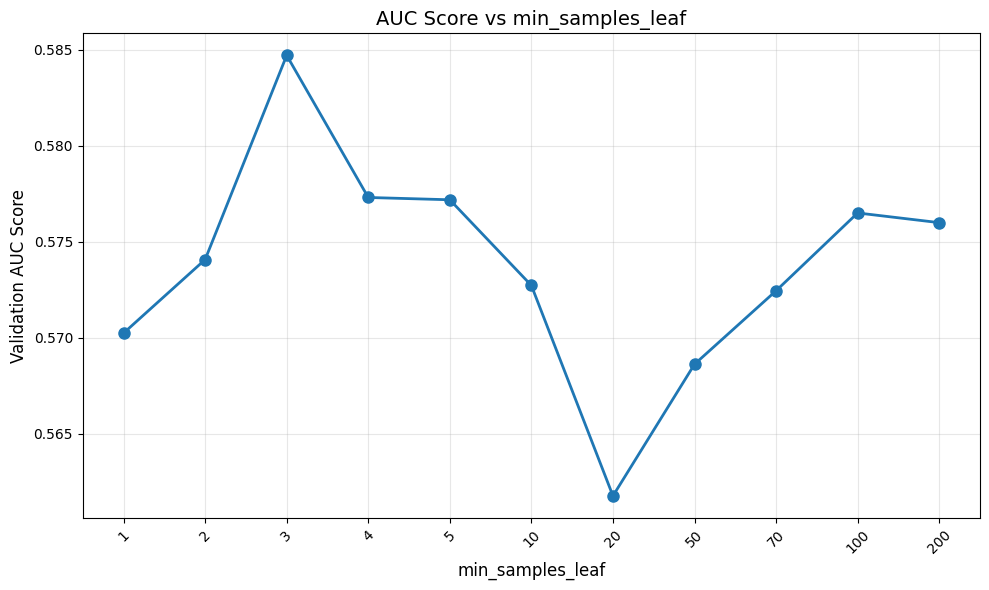

[0.5702352882169791,
 0.5740687583867796,
 0.5847120446156386,
 0.5773050825468516,
 0.5771853108280962,
 0.572718613206723,
 0.5617525930175004,
 0.5686144295681983,
 0.5724443854354081,
 0.5764982852026107,
 0.57599322413617]

In [90]:
print("\n=== TUNING min_samples_leaf (pre-pruning minimum leaf size) ===")
leaf_vals = [1, 2, 3, 4, 5, 10, 20, 50, 70, 100, 200]
tune_and_plot('min_samples_leaf', leaf_vals, 'min_samples_leaf')


=== TUNING max_features (feature sampling per split) ===
 max_features=7          -> AUC = 0.57474
 max_features=10         -> AUC = 0.57272
 max_features=20         -> AUC = 0.57583
 max_features=30         -> AUC = 0.56297
 max_features=40         -> AUC = 0.57077
 max_features=50         -> AUC = 0.57471
 max_features=60         -> AUC = 0.58674
 max_features=70         -> AUC = 0.58611
 max_features=80         -> AUC = 0.57200
 max_features=90         -> AUC = 0.56651
 max_features=100        -> AUC = 0.57742
 max_features=None       -> AUC = 0.52828


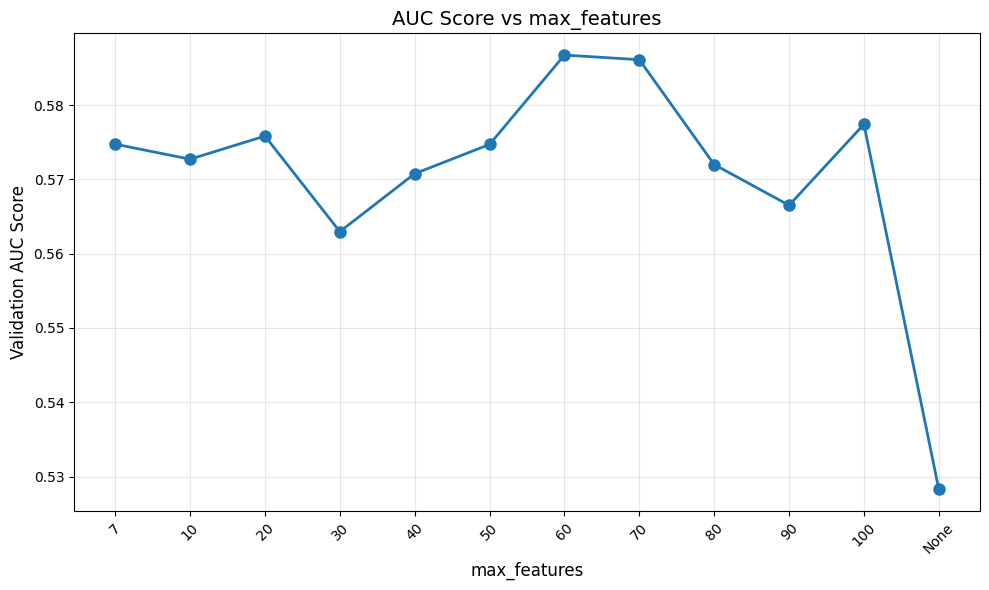

[0.574741060796994,
 0.572718613206723,
 0.5758329683325984,
 0.5629677515215608,
 0.5707714982828991,
 0.5747091826974049,
 0.5867388307521688,
 0.5861123554887026,
 0.5719975532281638,
 0.5665122156216629,
 0.5774188872622343,
 0.5282820556625069]

In [92]:
print("\n=== TUNING max_features (feature sampling per split) ===")
feature_vals = [7, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None]
tune_and_plot('max_features', feature_vals, 'max_features')


=== TUNING max_leaf_nodes (pre-pruning total leaf limit) ===
 max_leaf_nodes=20         -> AUC = 0.53306
 max_leaf_nodes=30         -> AUC = 0.53265
 max_leaf_nodes=40         -> AUC = 0.53210
 max_leaf_nodes=50         -> AUC = 0.53356
 max_leaf_nodes=70         -> AUC = 0.53409
 max_leaf_nodes=100        -> AUC = 0.53139
 max_leaf_nodes=150        -> AUC = 0.56194
 max_leaf_nodes=200        -> AUC = 0.56289
 max_leaf_nodes=300        -> AUC = 0.57393
 max_leaf_nodes=400        -> AUC = 0.57272
 max_leaf_nodes=500        -> AUC = 0.57272
 max_leaf_nodes=700        -> AUC = 0.57272
 max_leaf_nodes=None       -> AUC = 0.57272


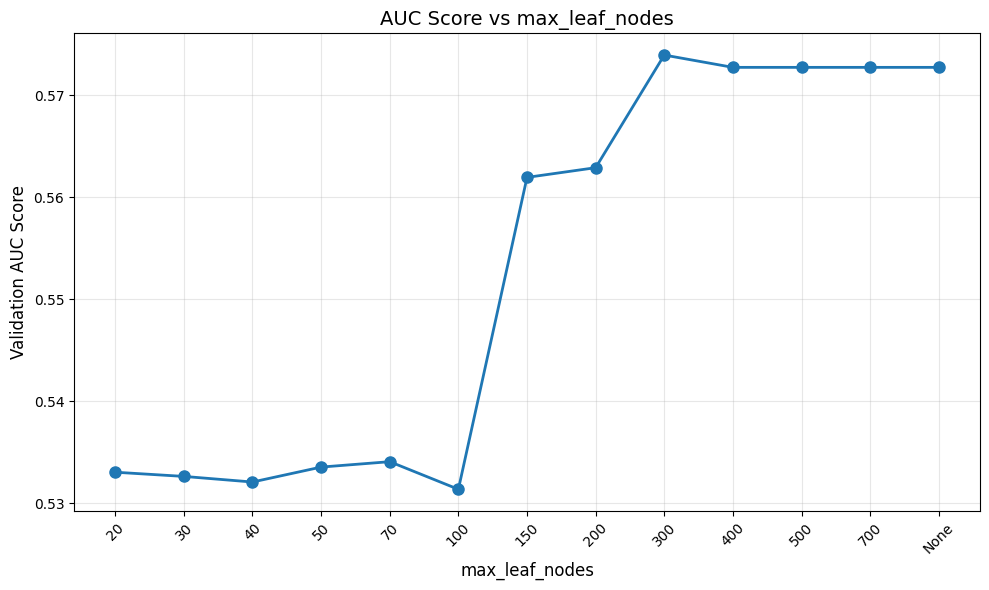

[0.533059325894469,
 0.5326478370153589,
 0.5320981816623831,
 0.5335620023628852,
 0.5340904947839596,
 0.5313851187502776,
 0.5619402071008862,
 0.562890968666983,
 0.5739251446938227,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723]

In [93]:
print("\n=== TUNING max_leaf_nodes (pre-pruning total leaf limit) ===")
leaf_node_vals = [20, 30, 40, 50, 70, 100, 150, 200, 300, 400, 500, 700, None]
tune_and_plot('max_leaf_nodes', leaf_node_vals, 'max_leaf_nodes')


=== TUNING min_impurity_decrease (minimum Gini gain) ===
 min_impurity_decrease=0.0        -> AUC = 0.57272
 min_impurity_decrease=1e-06      -> AUC = 0.57272
 min_impurity_decrease=1e-05      -> AUC = 0.57272
 min_impurity_decrease=2e-05      -> AUC = 0.57391
 min_impurity_decrease=5e-05      -> AUC = 0.55132
 min_impurity_decrease=0.0001     -> AUC = 0.53226
 min_impurity_decrease=0.0005     -> AUC = 0.50000
 min_impurity_decrease=0.001      -> AUC = 0.50000
 min_impurity_decrease=0.005      -> AUC = 0.50000
 min_impurity_decrease=0.01       -> AUC = 0.50000


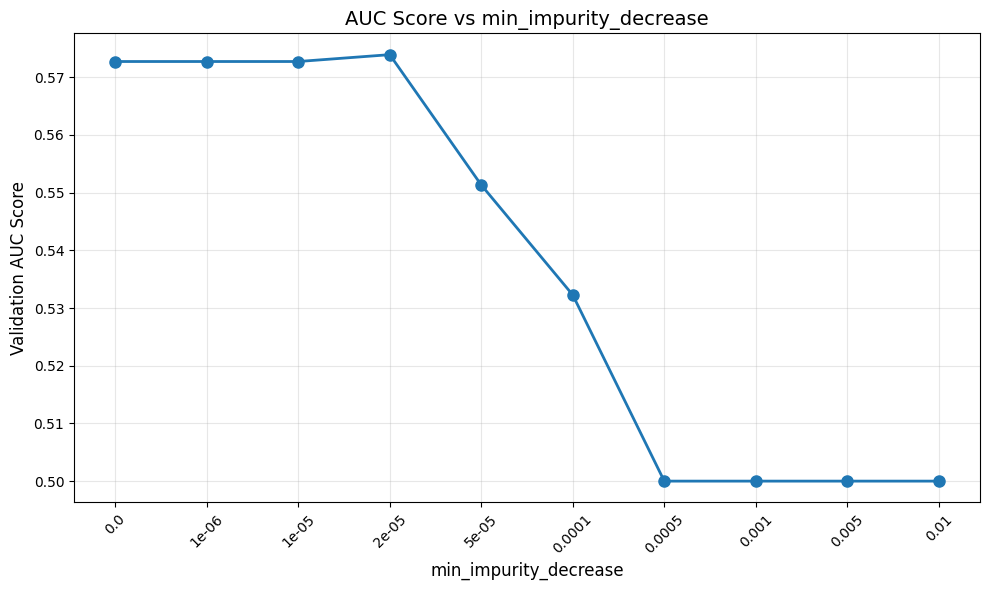

[0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.5739070984645893,
 0.5513205274911102,
 0.5322573067598776,
 0.5,
 0.5,
 0.5,
 0.5]

In [95]:
print("\n=== TUNING min_impurity_decrease (minimum Gini gain) ===")
impurity_vals = [0.0, 1e-6, 1e-5, 2e-5, 5e-5, 0.0001, 0.0005, 0.001, 0.005, 0.01]
tune_and_plot('min_impurity_decrease', impurity_vals, 'min_impurity_decrease')


=== TUNING min_cost_complexity (post-pruning alpha) ===
 min_cost_complexity=0.0        -> AUC = 0.57272
 min_cost_complexity=1e-06      -> AUC = 0.57272
 min_cost_complexity=1e-05      -> AUC = 0.57272
 min_cost_complexity=2e-05      -> AUC = 0.57272
 min_cost_complexity=0.0001     -> AUC = 0.57272
 min_cost_complexity=0.0005     -> AUC = 0.57272
 min_cost_complexity=0.005      -> AUC = 0.57272


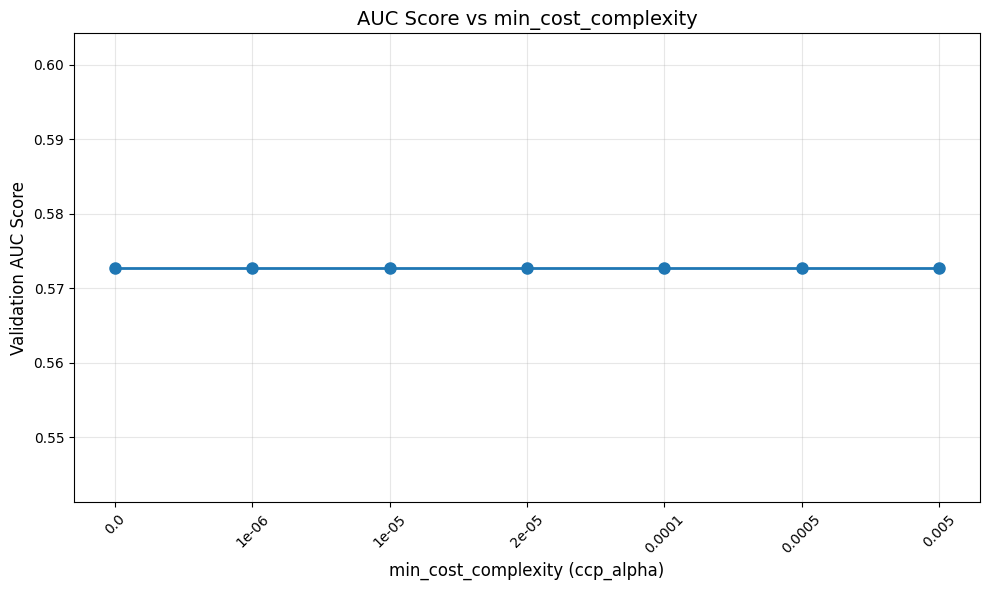

[0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723]

In [96]:
print("\n=== TUNING min_cost_complexity (post-pruning alpha) ===")
ccp_vals = [0.0, 1e-6, 1e-5, 2e-5, 1e-4, 5e-4, 5e-3]
tune_and_plot('min_cost_complexity', ccp_vals, 'min_cost_complexity (ccp_alpha)')


=== TUNING pos_weight (imbalance bias at leaves) ===
 pos_weight=1.0        -> AUC = 0.57272
 pos_weight=2.0        -> AUC = 0.57272
 pos_weight=5.0        -> AUC = 0.57272
 pos_weight=10.0       -> AUC = 0.57272
 pos_weight=20.0       -> AUC = 0.57272
 pos_weight=100        -> AUC = 0.57272
 pos_weight=1000       -> AUC = 0.57272
 pos_weight=10000      -> AUC = 0.57272
 pos_weight=100000000  -> AUC = 0.57272


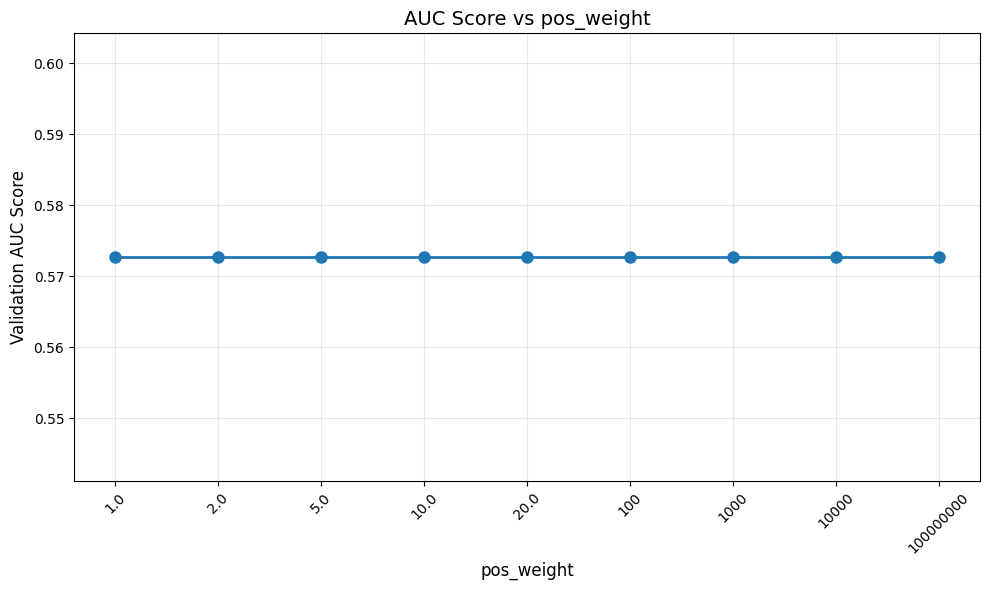

[0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723,
 0.572718613206723]

In [98]:
print("\n=== TUNING pos_weight (imbalance bias at leaves) ===")
weight_vals = [1.0, 2.0, 5.0, 10.0, 20.0, 100, 1000, 10000, 100000000]
tune_and_plot('pos_weight', weight_vals, 'pos_weight')

#### Model Training

##### Model - 1

In [101]:
# --- train Model ---

model_DT1 = DecisionTreeFromScratch_Opt_Time(
    max_depth = 6,
    min_samples_split = 10,
    min_samples_leaf = 3,
    max_features = 60,
    max_leaf_nodes = 300,
    min_impurity_decrease = 2e-5,
    min_cost_complexity = 0.0,
    pos_weight=5,
    random_state=42
)
import time
start = time.time()
model_DT1.fit(X_train, y_train)
end = time.time()
print("Model 1 training time: ", (end - start) / 60, "mins.")

Model 1 training time:  0.3131065527598063 mins.


In [102]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

# --- validation Score ---

valid_preds = model_DT1.predict_proba(X_valid)
auc = roc_auc_score(y_valid, valid_preds)
gini = 2 * auc - 1
print("Validation AUC:", auc)
print("Gini Validation: ", gini)

Validation AUC: 0.6055615576118182
Gini Validation:  0.21112311522363636


##### Model - 2

In [105]:
# --- train Model ---

model_DT2 = DecisionTreeFromScratch_Opt_Time(
    max_depth = 6,
    min_samples_split = 900,
    min_samples_leaf = 100,
    max_features = 70,
    max_leaf_nodes = 300,
    min_impurity_decrease = 2e-5,
    min_cost_complexity = 0.0,
    pos_weight=5,
    random_state=42
)
import time
start = time.time()
model_DT2.fit(X_train, y_train)
end = time.time()
print("Model 2 training time: ", (end - start) / 60, "mins.")

Model 2 training time:  0.3523353417714437 mins.


In [106]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

# --- validation Score ---

valid_preds = model_DT2.predict_proba(X_valid)
auc = roc_auc_score(y_valid, valid_preds)
gini = 2 * auc - 1
print("Validation AUC:", auc)
print("Gini Validation: ", gini)

Validation AUC: 0.6049289881530647
Gini Validation:  0.20985797630612946


##### Model - 3

In [109]:
# --- train Model ---

model_DT3 = DecisionTreeFromScratch_Opt_Time(
    max_depth = 6,
    min_samples_split = 50,
    min_samples_leaf = 20,
    max_features = 109,
    max_leaf_nodes = 300,
    min_impurity_decrease = 2e-5,
    min_cost_complexity = 0.0,
    pos_weight=10,
    random_state=42
)
import time
start = time.time()
model_DT3.fit(X_train, y_train)
end = time.time()
print("Model 3 training time: ", (end - start), "secs.")

Model 3 training time:  0.5432469725608826 mins.


In [110]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

# --- validation Score ---

valid_preds = model_DT3.predict_proba(X_valid)
auc = roc_auc_score(y_valid, valid_preds)
gini = 2 * auc - 1
print("Validation AUC:", auc)
print("Gini Validation: ", gini)

Validation AUC: 0.6061213833104218
Gini Validation:  0.21224276662084351


#### Best Model -> Model - 2 for Submission

In [111]:
# --- Test Prediction ---

test_preds = model_DT1.predict_proba(test)

# --- create submission ---

submission = pd.DataFrame({
    "id": test['id'],
    "target": test_preds.round(4)
})

submission

,id,target
0,0,0.0209
1,1,0.0263
2,2,0.0290
3,3,0.0290
4,4,0.0350
...,...,...
892811,1488022,0.0576
892812,1488023,0.0384
892813,1488024,0.0491
892814,1488025,0.0350


In [112]:
submission.to_csv("../Final-Submission/DT-submission_best.csv", index=False)

### Sklearn Model to Compare

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_DT_sklearn = DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_leaf=20, min_samples_split=50)
model_DT_sklearn.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [ ]:
y_preds_proba = model_DT_sklearn.predict_proba(X_valid)[:, 1]
print("AUC Score:", roc_auc_score(y_valid, y_preds_proba))


AUC Score: 0.6061213833104218
